## 5.1  Import Required Libraries

In [1]:
from pathlib import Path
from typing import Union, Optional
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, precision_recall_curve, auc
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
import logging


warnings.filterwarnings("ignore")

# Plotting style
plt.style.use("seaborn-v0_8-darkgrid")

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

## 5.2 Configuration and File Paths

In [2]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
CONFIG_DIR = BASE_DIR / "config"
MODEL_DIR = BASE_DIR / "models"
BRFSS_HARMONIZED_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
RECODED_CONFIG_FILE = CONFIG_DIR / "VALUE_RECODED_TEXT_MAP.json"

RANDOM_STATE = 42

## 5.3 Utility Functions

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

## 5.4 Load Dataset

In [4]:
df_raw = read_zipped_csv(BRFSS_HARMONIZED_CLEAN_ZIP_FILE)
logging.info(f"Initial data loaded with {df_raw.shape[0]} rows. and columns: {df_raw.shape[1]}")
logging.info(f"Years covered: {sorted(df_raw['YEAR'].unique())}")

2026-02-18 14:37:25 - INFO - Initial data loaded with 3101950 rows. and columns: 27
2026-02-18 14:37:25 - INFO - Years covered: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3101950 entries, 0 to 3101949
Data columns (total 27 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   YEAR                       int64  
 1   DIABETES                   float64
 2   AGE_CATEGORIES             int64  
 3   SEX                        float64
 4   RACE                       float64
 5   INCOME                     float64
 6   EDUCATION_LEVEL            int64  
 7   EMPLOYMENT                 float64
 8   MARITAL_STATUS             float64
 9   HEALTH_CARE_COVERAGE       float64
 10  BMICAT                     float64
 11  HEART_ATTACK               float64
 12  STROKE                     float64
 13  EXERCISE                   int64  
 14  SMOKER                     int64  
 15  HEAVY_ALCOHOL_CONSUMPTION  float64
 16  HEALTH_STATUS              int64  
 17  POOR_PHYSICAL_HEALTH_DAYS  int64  
 18  POOR_MENTAL_HEALTH_DAYS    int64  
 19  PRE_DIABETES               int64  
 20  GE

In [6]:
df_raw.head()

,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,...,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS,PRE_DIABETES,GEST_DIABETES,IS_YOUNG_ADULT,PANDEMIC_FLAG,RISK_OBESITY,RISK_INACTIVE,RISK_SMOKING,TOTAL_RISK_FACTORS
0,2015,0.0,8,0.0,0.0,1.0,1,2.0,5.0,1.0,...,2,2,0,0,0,0,1,1,1,3
1,2015,0.0,6,0.0,0.0,0.0,3,0.0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,2015,0.0,10,0.0,0.0,99.0,1,5.0,2.0,99.0,...,2,0,0,0,0,0,0,1,1,2
3,2015,0.0,8,0.0,0.0,4.0,1,2.0,5.0,1.0,...,2,2,0,0,0,0,0,1,1,2
4,2015,0.0,8,0.0,0.0,99.0,2,2.0,5.0,1.0,...,2,0,0,0,0,0,0,1,1,2


## 5.5  Feature Selection

In [7]:
# Select all columns except the target and some related features
features = [col for col in df_raw.columns if col not in ["YEAR", "DIABETES", "IS_YOUNG_ADULT", "PANDEMIC_FLAG", "RISK_OBESITY", "RISK_INACTIVE", "RISK_SMOKING"]]
target = "DIABETES"

X = df_raw[features]
y = df_raw[target]

## 5.6 Train Test Split

In [8]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=RANDOM_STATE, stratify=y_trainval)

logging.info(f"Training set: {X_train.shape[0]} samples, Validation set: {X_val.shape[0]} samples, Testing set: {X_test.shape[0]} samples")

2026-02-18 14:37:28 - INFO - Training set: 1985248 samples, Validation set: 496312 samples, Testing set: 620390 samples


## 5.7 Load the saved model

In [9]:
model = xgb.XGBClassifier()
model.load_model(MODEL_DIR / "xgb_diabetes_model.json")

## 5.8 Model Performance Metrics

In [10]:
y_pred = model.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
}

metrics

{'Accuracy': 0.7633005045213495,
 'Recall': 0.5662903722793355,
 'Precision': 0.37659039398925764,
 'F1 Score': 0.4523573330548739}

## 5.5  Diabetes Prevalence Overview

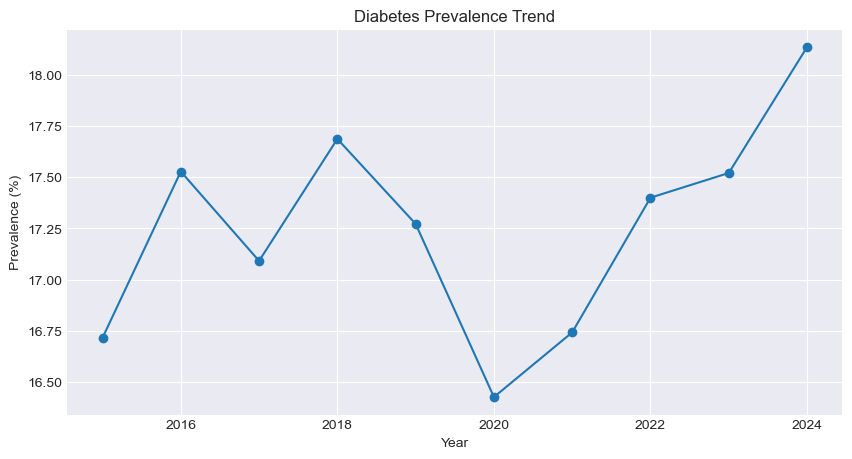

count    10.000000
mean     17.252080
std       0.515159
min      16.427658
25%      16.830454
50%      17.336116
75%      17.525855
max      18.134458
Name: DIABETES, dtype: float64

In [11]:
prev = df_raw.groupby("YEAR")[target].mean() * 100

plt.figure(figsize=(10,5))
prev.plot(marker="o")
plt.title("Diabetes Prevalence Trend")
plt.ylabel("Prevalence (%)")
plt.xlabel("Year")
plt.show()

prev.describe()

## 5.6 Generational Risk Shift (RQ1 Summary)

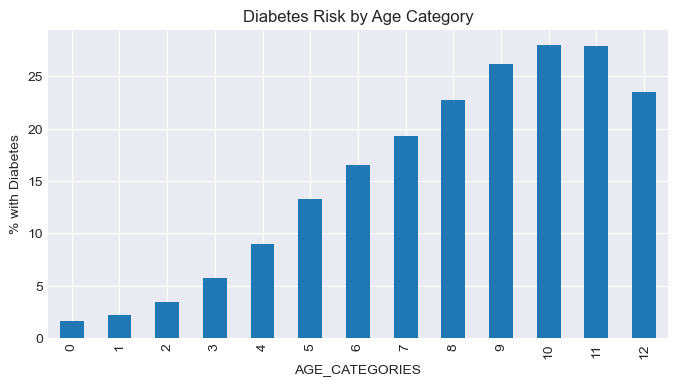

In [12]:
gen_risk = df_raw.groupby("AGE_CATEGORIES")[target].mean()*100
gen_risk.sort_index().plot(kind="bar", figsize=(8,4))
plt.title("Diabetes Risk by Age Category")
plt.ylabel("% with Diabetes")
plt.show()

## 5.7 Pandemic Impact Snapshot (RQ2 Summary)

In [13]:
pre = df_raw[df_raw["PANDEMIC_FLAG"] == 0][target].mean()
post = df_raw[df_raw["PANDEMIC_FLAG"] == 2][target].mean()

print("Pre-pandemic:", round(pre*100,2))
print("Post-pandemic:", round(post*100,2))

Pre-pandemic: 17.26
Post-pandemic: 17.69


## 5.8 Predictor Importance Snapshot (RQ3 Summary)

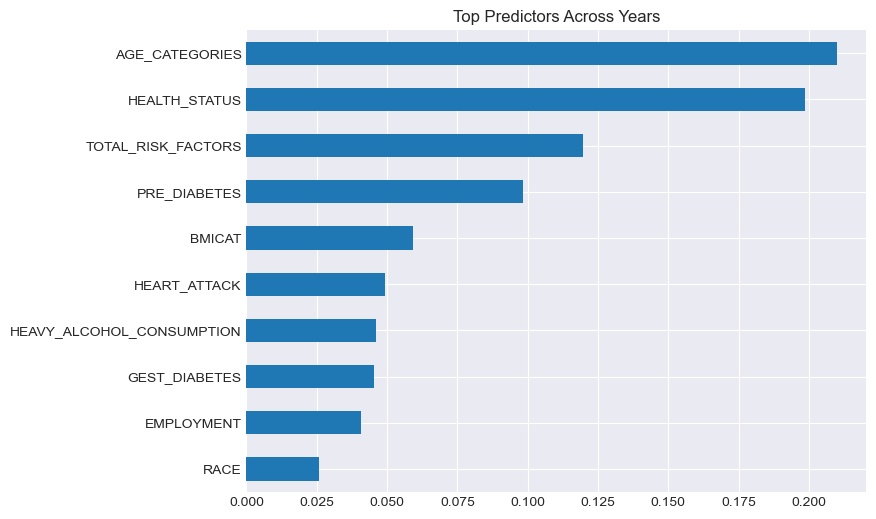

In [14]:
df_raw["YEAR"] = df_raw["YEAR"].astype(int)

years = sorted(df_raw["YEAR"].unique())
year_importance = []

for year in years:
    subset = df_raw[df_raw["YEAR"] == year]

    if len(subset) < 500:
        continue

    X_year = subset[features].astype("float32")
    y_year = subset[target]

    yearly_model = XGBClassifier(
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        n_estimators=150,
        max_depth=5,
        learning_rate=0.05,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )

    yearly_model.fit(X_year, y_year)
    year_importance.append(yearly_model.feature_importances_)

importance_df = pd.DataFrame(
    year_importance,
    columns=features,
    index=years[:len(year_importance)]
)
importances = importance_df.mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")
plt.title("Top Predictors Across Years")
plt.gca().invert_yaxis()
plt.show()

## 5.9 Compounding Risk Effect (RQ4 Summary)

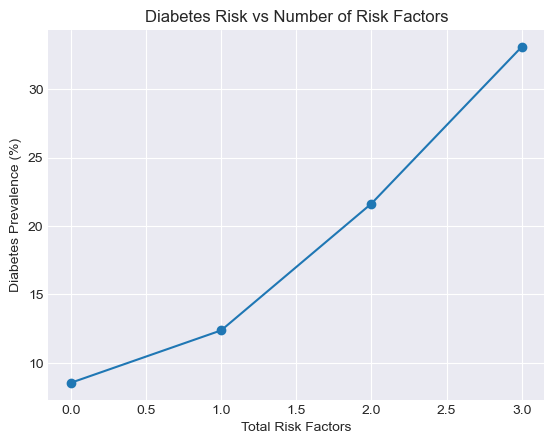

In [15]:
risk_counts = df_raw.groupby("TOTAL_RISK_FACTORS")["DIABETES"].mean()*100

risk_counts.plot(marker="o")
plt.title("Diabetes Risk vs Number of Risk Factors")
plt.ylabel("Diabetes Prevalence (%)")
plt.xlabel("Total Risk Factors")
plt.show()

## 5.10 Model Performance Snapshot

In [16]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

y_pred = model.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
}

metrics

{'Accuracy': 0.7633005045213495,
 'Recall': 0.5662903722793355,
 'Precision': 0.37659039398925764,
 'F1 Score': 0.4523573330548739}

## 5.11 Summarize

In [17]:
summary = pd.DataFrame({
    "Metric": metrics.keys(),
    "Value": metrics.values()
})

summary

,Metric,Value
0,Accuracy,0.763301
1,Recall,0.566290
2,Precision,0.376590
3,F1 Score,0.452357
